In [398]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.svm import OneClassSVM

In [399]:
df_m1 = pd.read_csv("m1_all.csv")
df_m1 = df_m1[df_m1["date"] >= '2021-01-01']
df_m2 = pd.read_csv("m2_repo_module_daily_signals.csv")
df_m2 = df_m2[df_m2["date"] >= '2021-01-01']
df_m3 = pd.read_csv("m3_ofz_auction_signals_daily.csv")
df_m3 = df_m3[df_m3["date"] >= '2021-01-01']
df_m4 = pd.read_csv("m4_all_new.csv")
df_m4 = df_m4[df_m4["date"] >= '2021-01-01']
df_m5 = pd.read_csv("m5_treasury_daily_signals.csv")
df_m5 = df_m5[df_m5["date"] >= '2021-01-01']

df = pd.DataFrame({"date": pd.date_range('2021-01-01', '2026-05-08')})
df_m4["date"] = pd.to_datetime(df_m4["date"])
df_m2["date"] = pd.to_datetime(df_m2["date"])
df_m1["date"] = pd.to_datetime(df_m1["date"])
df_m5["date"] = pd.to_datetime(df_m5["date"])
df_m3["date"] = pd.to_datetime(df_m3["date"])

coloms = ['mad_score_ruonia', 'mad_score_spread',"flag_end_period", 
           'MAD_score_rate_spread', "MAD_score_cover", "Flag_Demand",
          'MAD_score_repo_volume', "Tax_Week_Flag","End_of_Month_Flag","End_of_Quarter_Flag","Seasonal_Factor",
          "MAD_score_yield_spread","Flag_Nedospros","Flag_Perespros"
          "MAD_score_CBR","MAD_score_Roskazna","Flag_Budget_Drain","Flag_Treasury_Placement_Drop"]

for col in coloms:
    if col in ['mad_score_ruonia', 'mad_score_spread',"flag_end_period"]:
        mapping = df_m1.set_index('date')[col]
    elif col in ['MAD_score_rate_spread', "MAD_score_cover", "Flag_Demand",'MAD_score_repo_volume']:
        mapping = df_m2.set_index('date')[col]
    elif col in ["Tax_Week_Flag","End_of_Month_Flag","End_of_Quarter_Flag","Seasonal_Factor"]:
        mapping = df_m4.set_index('date')[col]
    elif col in ["MAD_score_yield_spread","Flag_Nedospros","Flag_Perespros"]:
        mapping = df_m3.set_index('date')[col]
    elif col in ["MAD_score_CBR","MAD_score_Roskazna","Flag_Budget_Drain","Flag_Treasury_Placement_Drop"]:
        mapping = df_m5.set_index('date')[col]
    df[col] = df['date'].map(mapping)
mapping = df_m3.set_index('date')["MAD_score_cover"]
df["MAD_score_cover_m3"] = df["date"].map(mapping)
data = pd.DataFrame()
data["date"] = df["date"]
df.drop(["date"], axis = 1, inplace=True)
df = df.dropna()
df.to_csv(r"C:\Users\Viktoria\Documents\MAI\Matmod\RU-Liquidity-Sentinel\ml-services\llm\all_newdf.csv")
df.drop(["Seasonal_Factor", "Flag_Demand"], axis =1, inplace=True)
df.head()



,mad_score_ruonia,mad_score_spread,flag_end_period,MAD_score_rate_spread,MAD_score_cover,MAD_score_repo_volume,Tax_Week_Flag,End_of_Month_Flag,End_of_Quarter_Flag,MAD_score_yield_spread,Flag_Nedospros,Flag_PeresprosMAD_score_CBR,MAD_score_Roskazna,Flag_Budget_Drain,Flag_Treasury_Placement_Drop,MAD_score_cover_m3
10,-3.030303,1.703488,1.0,0.0,0.0,0.0,1,0,0,-4.615884,0.0,0.0,0.0,False,False,1.736145
11,-3.121212,1.703488,1.0,0.0,0.0,0.0,1,0,0,-4.615884,0.0,0.0,0.0,False,False,1.736145
12,-3.070707,-1.255814,1.0,0.0,0.0,0.0,1,0,0,-2.758662,1.0,1.0,0.0,False,False,-0.766198
13,-3.060606,-1.255814,0.0,0.0,0.0,0.0,1,0,0,-2.758662,0.0,0.0,0.0,False,False,-0.766198
14,-3.050505,-1.255814,0.0,0.0,0.0,0.0,1,0,0,-2.744315,0.0,0.0,0.0,False,False,-0.765277


<function matplotlib.pyplot.show(close=None, block=None)>

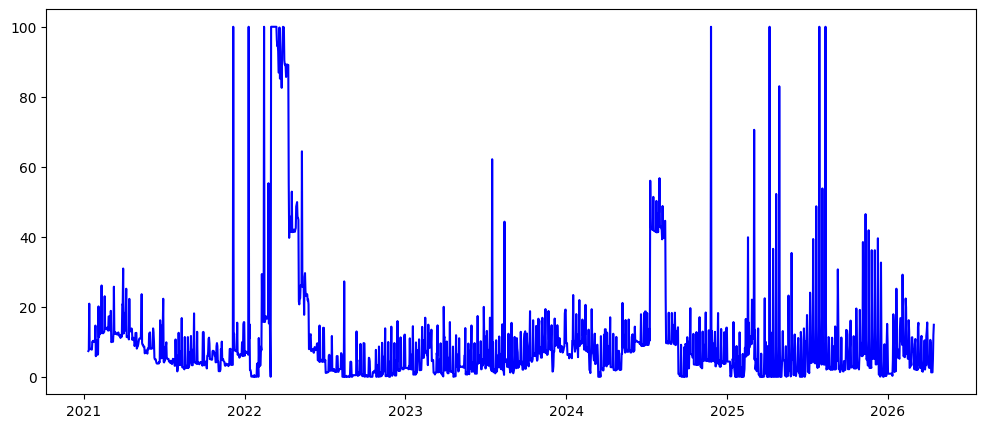

In [400]:
import matplotlib.pyplot as plt
import shap

scaler = RobustScaler()
X_scaled = scaler.fit_transform(df)

n_components = 5
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)


X_reconstructed = pca.inverse_transform(X_pca)
reconstruction_error = np.sum((X_scaled - X_reconstructed) ** 2, axis=1)

df['pca_error'] = reconstruction_error

threshold = np.percentile(reconstruction_error, 95)
q_low = np.quantile(reconstruction_error, 0.05)
q_high = np.quantile(reconstruction_error, 0.99)

score = 100 * (reconstruction_error - q_low) / (q_high - q_low)
score = np.clip(score, 0, 100)

df["LSI"] = score
df["date"] = data["date"]
plt.figure(figsize=(12, 5))
#mask = (df['date'] >= '2021-06-01') & (df['date'] <= '2022-06-30')
#plt.plot(df.loc[mask, "date"], df.loc[mask, "LSI"],color='blue', linewidth=1.5)
plt.plot(df["date"], df["LSI"],color='blue', linewidth=1.5)
plt.show

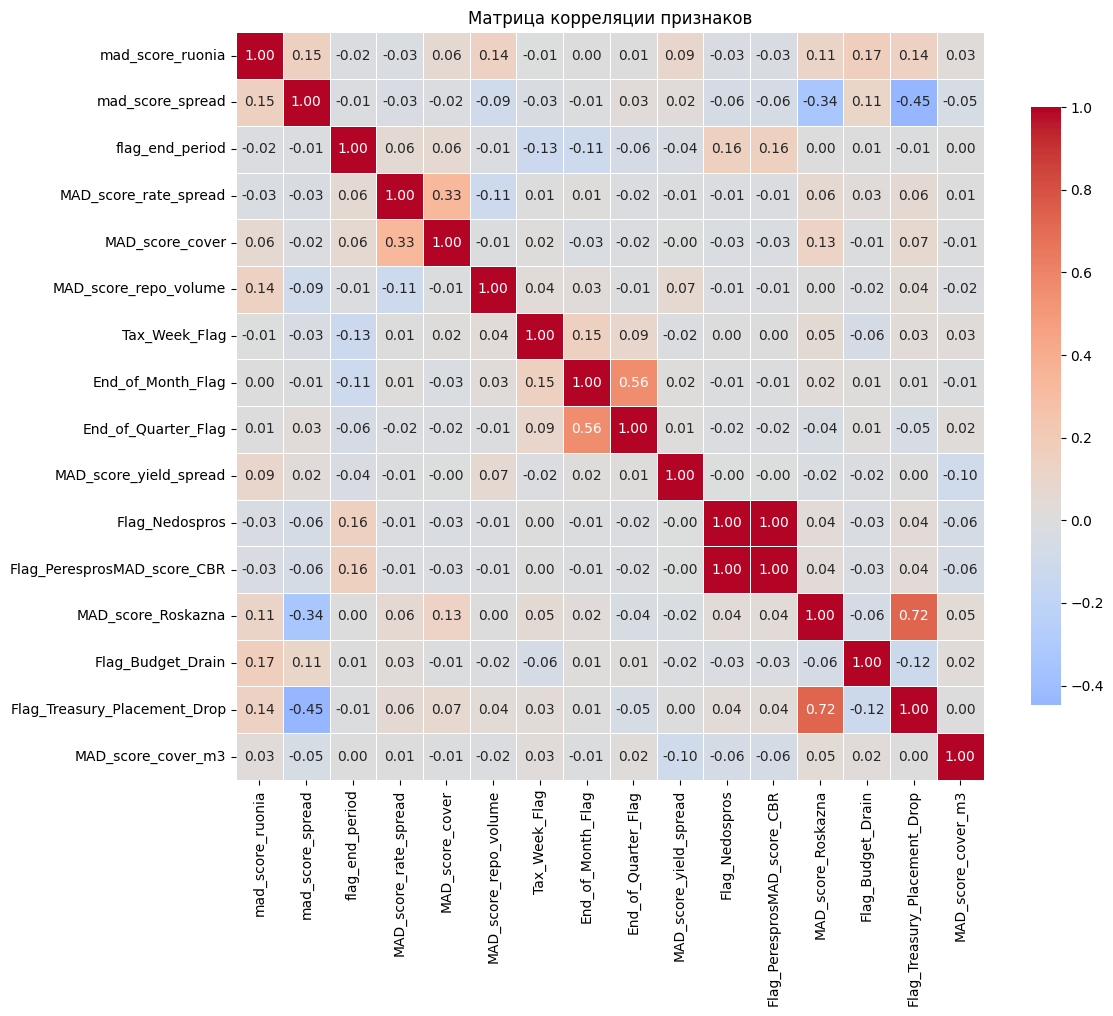

In [401]:
df.drop(["date", "LSI", "pca_error"], axis=1, inplace=True)
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляции признаков')
plt.tight_layout()
plt.show()

c:\Users\Viktoria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
  0%|          | 0/10 [00:00<?, ?it/s]c:\Users\Viktoria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
c:\Users\Viktoria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
 10%|█         | 1/10 [00:00<00:01,  8.40it/s]c:\Users\Viktoria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
c:\Users\Viktoria\AppData\Local\Programs\Python\Python311\Lib\site-packa

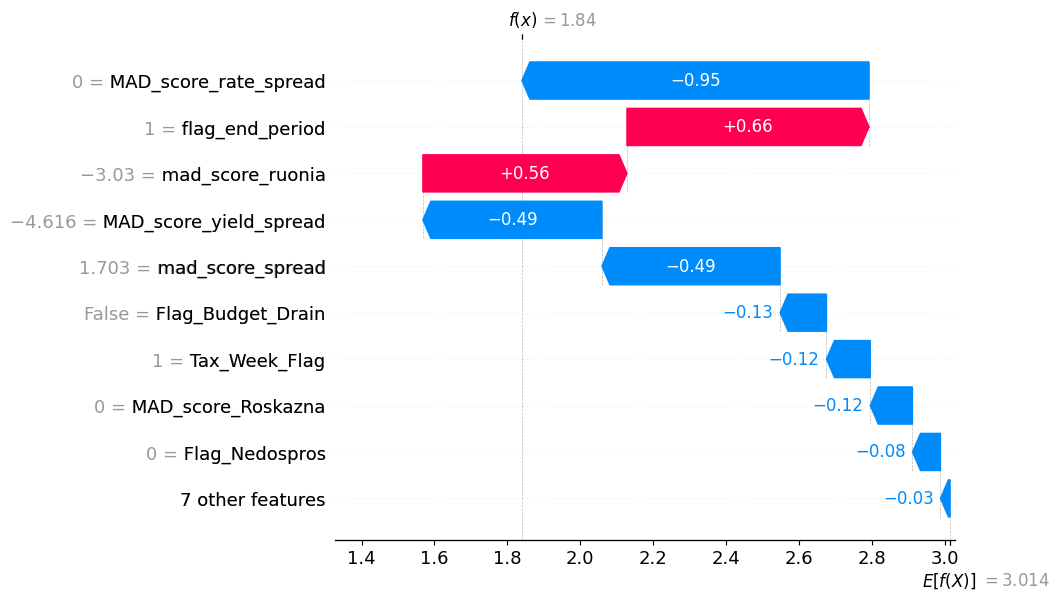

None


In [402]:
def predict_error(X):
    X_scaled = scaler.transform(X)
    X_recon = pca.inverse_transform(pca.transform(X_scaled))
    error = np.sum((X_scaled - X_recon) ** 2, axis=1)
    return error

background = df.sample(100, random_state=42)
explainer = shap.KernelExplainer(predict_error, background)
X_to_explain = df.iloc[:10]
shap_values = explainer.shap_values(X_to_explain, nsamples=100)
print(shap.waterfall_plot(shap.Explanation(values=shap_values[0], base_values=explainer.expected_value,data=X_to_explain.iloc[0])))

In [403]:
s = df["LSI"]

print(s.describe())
print(">=80: ", (s >= 80).mean())
print("== 100: ", (s == 100).sum())

KeyError: 'LSI'

In [ ]:
svm = OneClassSVM(
    kernel="rbf",
    nu=0.03,
    gamma="scale",
)

svm.fit(X_scaled)

decision = svm.decision_function(X_scaled)
anomaly_raw = -decision

q_low = np.quantile(anomaly_raw, 0.01)
q_high = np.quantile(anomaly_raw, 0.99)

svm_score = 100 * (anomaly_raw - q_low) / (q_high - q_low)
svm_score = np.clip(svm_score, 0, 100)

df["SVM_LSI"] = svm_score

<function matplotlib.pyplot.show(close=None, block=None)>

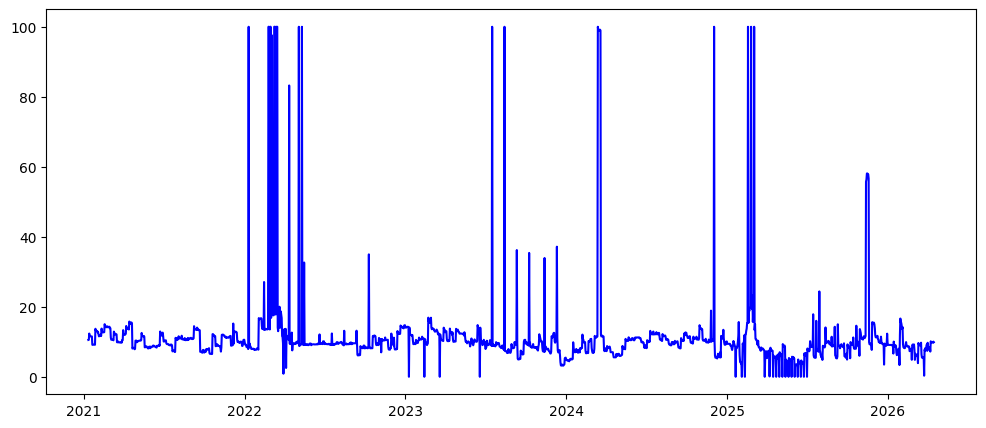

In [ ]:
df["date"] = data["date"]
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["SVM_LSI"],color='blue', linewidth=1.5)
plt.show

In [ ]:
s = df["SVM_LSI"]

print(s.describe())
print(">=80: ", (s >= 80).mean())
print("== 100: ", (s == 100).sum())

count    1921.000000
mean       11.219842
std        11.555659
min         0.000000
25%         8.211585
50%         9.554373
75%        11.245241
max       100.000000
Name: SVM_LSI, dtype: float64
>=80:  0.014575741801145237
== 100:  20
